In [9]:
%matplotlib inline

# Making a Radar Chart for Lionel Messi 17/18

In [10]:
import pandas as pd
import numpy as np
import json
# plotting
import matplotlib.pyplot as plt
# statistical fitting of models
import statsmodels.api as sm
import statsmodels.formula.api as smf
#opening data
import os
import pathlib
import warnings 
#used for plots
from scipy import stats
from mplsoccer import PyPizza, FontManager

pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore')

### Load and Preprocess LaLiga Data

In [11]:
# load LaLiga data
train_laliga = pd.DataFrame()
file_name = 'events_Spain.json'
path = os.path.join(str(pathlib.Path().resolve().parents[0]), 'data', 'Wyscout', 'events', file_name)
with open(path) as f:
    data = json.load(f)
train_laliga = pd.concat([train_laliga, pd.DataFrame(data)], ignore_index = True)
#potential data collection error handling
train_laliga = train_laliga.loc[train_laliga.apply (lambda x: len(x.positions) == 2, axis = 1)]

In [12]:
def calculate_xG(df, npxG):
    """
    Parameters
    ----------
    df : dataframe
        dataframe with Wyscout event data.
    npxG : boolean
        True if xG should not include penalties, False elsewhere.

    Returns
    -------
    xG_sum: dataframe
        dataframe with sum of Expected Goals for players during the season.

    """
    #very basic xG model based on 
    shots = df.loc[df["eventName"] == "Shot"].copy()
    shots["X"] = shots.positions.apply(lambda cell: (100 - cell[0]['x']) * 105/100)
    shots["Y"] = shots.positions.apply(lambda cell: cell[0]['y'] * 68/100)
    shots["C"] = shots.positions.apply(lambda cell: abs(cell[0]['y'] - 50) * 68/100)
    #calculate distance and angle 
    shots["Distance"] = np.sqrt(shots["X"]**2 + shots["C"]**2)
    shots["Angle"] = np.where(np.arctan(7.32 * shots["X"] / (shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) > 0, np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)), np.arctan(7.32 * shots["X"] /(shots["X"]**2 + shots["C"]**2 - (7.32/2)**2)) + np.pi)
    #if you ever encounter problems (like you have seen that model treats 0 as 1 and 1 as 0) while modelling - change the dependant variable to object 
    shots["Goal"] = shots.tags.apply(lambda x: 1 if {'id':101} in x else 0).astype(object)
        #headers have id = 403
    headers = shots.loc[shots.apply (lambda x:{'id':403} in x.tags, axis = 1)]
    non_headers = shots.drop(headers.index)
    
    headers_model = smf.glm(formula="Goal ~ Distance + Angle" , data=headers, 
                               family=sm.families.Binomial()).fit()
    #non-headers
    nonheaders_model = smf.glm(formula="Goal ~ Distance + Angle" , data=non_headers, 
                               family=sm.families.Binomial()).fit()
    #assigning xG
    #headers
    b_head = headers_model.params
    xG = 1/(1+np.exp(b_head["Intercept"]+b_head["Distance"]*headers['Distance'] + b_head["Angle"]*headers['Angle'])) 
    headers = headers.assign(xG = xG)

    #non-headers 
    b_nhead = nonheaders_model.params
    xG = 1/(1+np.exp(b_nhead["Intercept"]+b_nhead["Distance"]*non_headers['Distance'] + b_nhead["Angle"]*non_headers['Angle'])) 
    non_headers = non_headers.assign(xG = xG)
    
    if npxG == False:
        #find pens
        penalties = df.loc[df["subEventName"] == "Penalty"]
        #assign 0.8
        penalties = penalties.assign(xG = 0.8)
        #concat, group and sum
        all_shots_xg = pd.concat([non_headers[["playerId", "xG"]], headers[["playerId", "xG"]], penalties[["playerId", "xG"]]])
        xG_sum = all_shots_xg.groupby(["playerId"])["xG"].sum().sort_values(ascending = False).reset_index()
    else:
        #concat, group and sum
        all_shots_xg = pd.concat([non_headers[["playerId", "xG"]], headers[["playerId", "xG"]]]) 
        all_shots_xg.rename(columns = {"xG": "npxG"}, inplace = True)
        xG_sum = all_shots_xg.groupby(["playerId"])["npxG"].sum().sort_values(ascending = False).reset_index()
    #group by player and sum 
    
    return xG_sum

# calculate xG with the function for all players
laliga_xG = calculate_xG(train_laliga, npxG = True)
laliga_xG.head(3)

,playerId,npxG
0,3322,23.346131
1,7972,20.596689
2,3359,18.064101


In [13]:
def FinalThird(df):
    """
    Parameters
    ----------
    df : dataframe
        dataframe with Wyscout event data.

    Returns
    -------
    final_third: dataframe
        dataframe with number of passes ending in final third and receptions in that area for a player. 

    """
    df = df.copy()
    #need player who had received the ball
    df["nextPlayerId"] = df["playerId"].shift(-1)
    passes = df.loc[df["eventName"] == "Pass"].copy()
    #changing coordinates
    passes["x"] = passes.positions.apply(lambda cell: (cell[0]['x']) * 105/100)
    passes["y"] = passes.positions.apply(lambda cell: (100 - cell[0]['y']) * 68/100)
    passes["end_x"] = passes.positions.apply(lambda cell: (cell[1]['x']) * 105/100)
    passes["end_y"] = passes.positions.apply(lambda cell: (100 - cell[1]['y']) * 68/100)
    
    #get accurate passes
    accurate_passes = passes.loc[passes.apply (lambda x:{'id':1801} in x.tags, axis = 1)]
    #get passes into final third
    final_third_passes = accurate_passes.loc[accurate_passes["end_x"] > 2*105/3]
    
    #passes into final third by player
    ftp_player = final_third_passes.groupby(["playerId"]).end_x.count().reset_index()
    ftp_player.rename(columns = {'end_x':'final_third_passes'}, inplace=True)
    
    #receptions of accurate passes in the final third
    rtp_player = final_third_passes.groupby(["nextPlayerId"]).end_x.count().reset_index()
    rtp_player.rename(columns = {'end_x':'final_third_receptions', "nextPlayerId": "playerId"}, inplace=True)
    
    #outer join not to lose values
    final_third = ftp_player.merge(rtp_player, how = "outer", on = ["playerId"])
    return final_third

# calculate passes into final third and receptions in that area for all players
laliga_final_third = FinalThird(train_laliga)
laliga_final_third.head(3)

,playerId,final_third_passes,final_third_receptions
0,0.0,1.0,23.0
1,151.0,139.0,163.0
2,254.0,375.0,355.0


In [14]:
def wonDuels(df):
    """
    Parameters
    ----------
    df : dataframe
        dataframe with Wyscout event data.

    Returns
    -------
    duels_won: dataframe
        dataframe with number of won air and ground duels for a player 

    """
    #find air duels
    air_duels = df.loc[df["subEventName"] == "Air duel"]
    #703 is the id of a won duel
    won_air_duels = air_duels.loc[air_duels.apply (lambda x:{'id':703} in x.tags, axis = 1)]
    
    #group and sum air duels
    wad_player =  won_air_duels.groupby(["playerId"]).eventId.count().reset_index()
    wad_player.rename(columns = {'eventId':'air_duels_won'}, inplace=True)
    
    #find ground duels won
    ground_duels = df.loc[df["subEventName"].isin(["Ground attacking duel"])]
    won_ground_duels = ground_duels.loc[ground_duels.apply (lambda x:{'id':703} in x.tags, axis = 1)]
    
    wgd_player =  won_ground_duels.groupby(["playerId"]).eventId.count().reset_index()
    wgd_player.rename(columns = {'eventId':'ground_duels_won'}, inplace=True)
    
    #outer join
    duels_won = wgd_player.merge(wad_player, how = "outer", on = ["playerId"])
    return duels_won

# calculate air and ground duels won for all players
laliga_duels = wonDuels(train_laliga)
laliga_duels.head(3)

,playerId,ground_duels_won,air_duels_won
0,0,2282.0,936.0
1,151,48.0,33.0
2,254,53.0,62.0


In [15]:
def smartPasses(df):
    """
    Parameters
    ----------
    df : dataframe
        dataframe with Wyscout event data.

    Returns
    -------
    sp_player: dataframe
        dataframe with number of smart passes.

    """
    #get smart passes
    smart_passes = df.loc[df["subEventName"] == "Smart pass"]
    #find accurate
    smart_passes_made = smart_passes.loc[smart_passes.apply (lambda x:{'id':1801} in x.tags, axis = 1)]
    
    #sum by player
    sp_player =  smart_passes_made.groupby(["playerId"]).eventId.count().reset_index()
    sp_player.rename(columns = {'eventId':'smart_passes'}, inplace=True)
    
    return sp_player


# calculate smart passes for all players
laliga_smart_passes = smartPasses(train_laliga)
laliga_smart_passes.head(3)

,playerId,smart_passes
0,151,6
1,254,6
2,1751,3


In [16]:
def GoalsAssistsKeyPasses(df):
    """
    Parameters
    ----------
    df : dataframe
        dataframe with Wyscout event data.

    Returns
    -------
    data: dataframe
        dataframe with number of (non-penalty) goals, assists and key passes.

    """
    #get goals
    shots = df.loc[df["subEventName"] == "Shot"]
    goals = shots.loc[shots.apply (lambda x:{'id':101} in x.tags, axis = 1)]
    #get assists
    passes = df.loc[df["eventName"] == "Pass"]
    assists = passes.loc[passes.apply (lambda x:{'id':301} in x.tags, axis = 1)]
    #get key passes
    key_passes = passes.loc[passes.apply (lambda x:{'id':302} in x.tags, axis = 1)]
    
    #goals by player
    g_player =  goals.groupby(["playerId"]).eventId.count().reset_index()
    g_player.rename(columns = {'eventId':'goals'}, inplace=True)
    
    #assists by player
    a_player =  assists.groupby(["playerId"]).eventId.count().reset_index()
    a_player.rename(columns = {'eventId':'assists'}, inplace=True)
    
    #key passes by player
    kp_player =  key_passes.groupby(["playerId"]).eventId.count().reset_index()
    kp_player.rename(columns = {'eventId':'key_passes'}, inplace=True)
    
    data = g_player.merge(a_player, how = "outer", on = ["playerId"]).merge(kp_player, how = "outer", on = ["playerId"])
    return data


# calculate non-penalty goals, assists and key passes for all players
laliga_gakp = GoalsAssistsKeyPasses(train_laliga)
laliga_gakp.head(3)

,playerId,goals,assists,key_passes
0,151,3.0,3.0,4.0
1,254,1.0,NaN,12.0
2,1751,NaN,NaN,2.0


In [17]:
path = os.path.join(str(pathlib.Path().resolve().parents[0]),"minutes_played", 'minutes_played_per_game_Spain.json')
with open(path) as f:
    minutes_per_game = json.load(f)
minutes_per_game = pd.DataFrame(minutes_per_game)
minutes = minutes_per_game.groupby(["playerId"]).minutesPlayed.sum().reset_index()

In [18]:
# summary table
players = train_laliga["playerId"].unique()
summary_laliga = pd.DataFrame(players, columns = ["playerId"])
summary_laliga = summary_laliga.merge(laliga_xG, how = "left", on = ["playerId"]).merge(laliga_final_third, how = "left", on = ["playerId"]).merge(laliga_duels, how = "left", on = ["playerId"]).merge(laliga_smart_passes, how = "left", on = ["playerId"]).merge(laliga_gakp, how = "left", on = ["playerId"])
summary_laliga = minutes.merge(summary_laliga, how = "left", on = ["playerId"])
summary_laliga = summary_laliga.fillna(0)
summary_laliga = summary_laliga.loc[summary_laliga["minutesPlayed"] > 400]
summary_laliga.head(3)    

,playerId,minutesPlayed,npxG,final_third_passes,final_third_receptions,ground_duels_won,air_duels_won,smart_passes,goals,assists,key_passes
2,151,1379,3.006069,139.0,163.0,48.0,33.0,6.0,3.0,3.0,4.0
3,254,3230,0.504181,375.0,355.0,53.0,62.0,6.0,1.0,0.0,12.0
5,1751,597,0.859322,85.0,107.0,40.0,0.0,3.0,0.0,0.0,2.0


In [20]:
path = os.path.join(str(pathlib.Path().resolve().parents[0]),"data", 'Wyscout', 'players.json')
with open(path) as f:
    players = json.load(f)
player_df = pd.DataFrame(players)
forwards = player_df.loc[player_df.apply(lambda x: x.role["name"] == "Forward", axis = 1)]
forwards.rename(columns = {'wyId':'playerId'}, inplace=True)
to_merge = forwards[['playerId', 'shortName']]
summary_laliga = summary_laliga.merge(to_merge, how = "inner", on = ["playerId"])

In [22]:
# summary per 90
summary_per_90_laliga = pd.DataFrame()
summary_per_90_laliga["shortName"] = summary_laliga["shortName"]
for column in summary_laliga.columns[2:-1]:
    summary_per_90_laliga[column + "_per90"] = summary_laliga.apply(lambda x: x[column]*90/x["minutesPlayed"], axis = 1)

In [23]:
# calculating posession for laliga players

possesion_dict = {}
#for every row in the dataframe
for i, row in minutes_per_game.iterrows():
    #take player id, team id and match id, minute in and minute out
    player_id, team_id, match_id = row["playerId"], row["teamId"], row["matchId"]
    #create a key in dictionary if player encounterd first time
    if not str(player_id) in possesion_dict.keys():
        possesion_dict[str(player_id)] = {'team_passes': 0, 'all_passes' : 0}
    min_in = row["player_in_min"]*60
    min_out = row["player_out_min"]*60
    
    #get the dataframe of events from the game
    match_df = train_laliga.loc[train_laliga["matchId"] == match_id].copy()
    #add to 2H the highest value of 1H
    match_df.loc[match_df["matchPeriod"] == "2H", 'eventSec'] = match_df.loc[match_df["matchPeriod"] == "2H", 'eventSec'] + match_df.loc[match_df["matchPeriod"] == "1H"]["eventSec"].iloc[-1]
    #take all events from this game and this period
    player_in_match_df = match_df.loc[match_df["eventSec"] > min_in].loc[match_df["eventSec"] <= min_out]
    #take all passes and won duels as described
    all_passes = player_in_match_df.loc[player_in_match_df["eventName"].isin(["Pass", "Duel"])]
    #adjusting for no passes in this period (Tuanzebe)
    if len(all_passes) > 0:
        #removing lost air duels
        no_contact = all_passes.loc[all_passes["subEventName"].isin(["Air duel", "Ground defending duel","Ground loose ball duel"])].loc[all_passes.apply(lambda x:{'id':701} in x.tags, axis = 1)]
        all_passes = all_passes.drop(no_contact.index)
    #take team passes 
    team_passes = all_passes.loc[all_passes["teamId"] == team_id]
    #append it {player id: {team passes: sum, all passes : sum}}
    possesion_dict[str(player_id)]["team_passes"] += len(team_passes)
    possesion_dict[str(player_id)]["all_passes"] += len(all_passes)

#calculate possesion for each player
percentage_dict = {key: value["team_passes"]/value["all_passes"] if value["all_passes"] > 0 else 0 for key, value in possesion_dict.items()}
#create a dataframe
percentage_df = pd.DataFrame(percentage_dict.items(), columns = ["playerId", "possesion"])
percentage_df["playerId"] = percentage_df["playerId"].astype(int)
#merge it
summary_laliga = summary_laliga.merge(percentage_df, how = "left", on = ["playerId"])


In [24]:
# adjust per 90 values for possesion
summary_adjusted_laliga = pd.DataFrame()
summary_adjusted_laliga["shortName"] = summary_laliga["shortName"]
for column in summary_laliga.columns[2:11]:
    summary_adjusted_laliga[column + "_adjusted_per90"] = summary_laliga.apply(lambda x: (x[column]/x["possesion"])*90/x["minutesPlayed"], axis = 1)

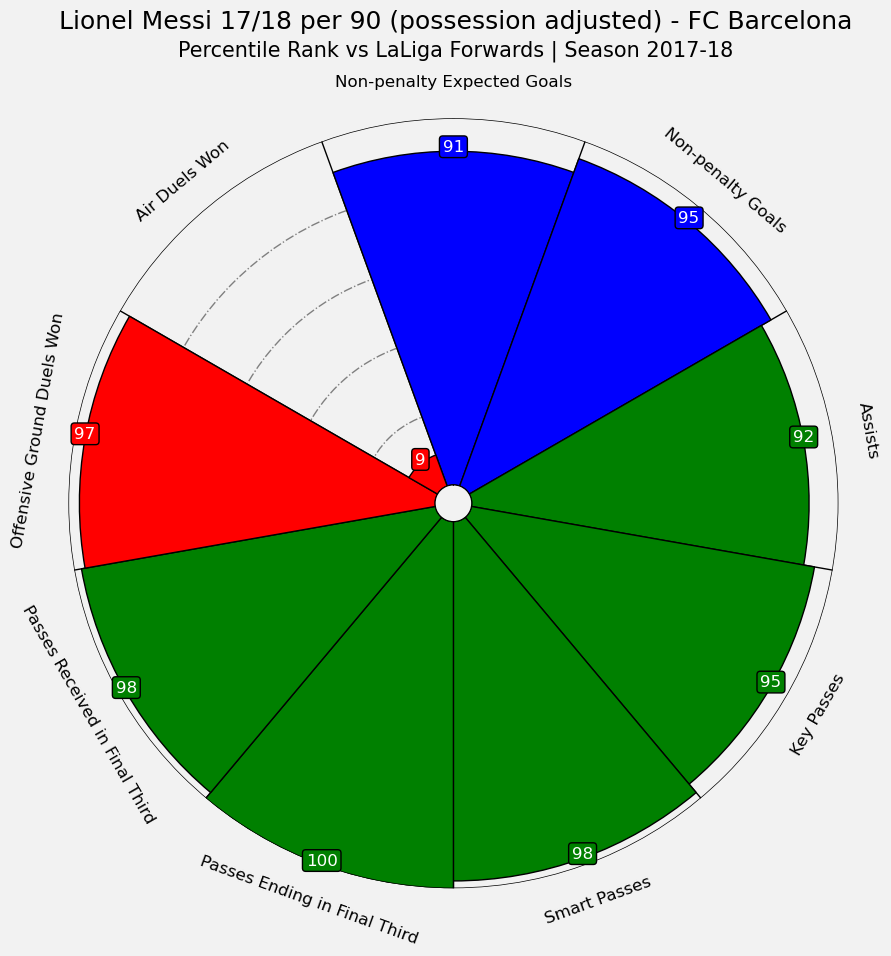

In [26]:
# make pizza plot for Messi
messi_adjusted = summary_adjusted_laliga.loc[summary_adjusted_laliga["shortName"] == "L. Messi"]
messi_adjusted = messi_adjusted[['npxG_adjusted_per90', "goals_adjusted_per90", "assists_adjusted_per90", "key_passes_adjusted_per90", "smart_passes_adjusted_per90", "final_third_passes_adjusted_per90", "final_third_receptions_adjusted_per90", "ground_duels_won_adjusted_per90", "air_duels_won_adjusted_per90"]]
adjusted_columns = messi_adjusted.columns[:]
values = [messi_adjusted[column].iloc[0] for column in adjusted_columns]
percentiles = [int(stats.percentileofscore(summary_adjusted_laliga[column], messi_adjusted[column].iloc[0])) for column in adjusted_columns]

names = ["Non-penalty Expected Goals", "Non-penalty Goals", "Assists", "Key Passes", "Smart Passes", "Passes Ending in Final Third", "Passes Received in Final Third", "Offensive Ground Duels Won", "Air Duels Won"]
slice_colors = ["blue"] * 2 + ["green"] * 5 + ["red"] * 2
text_colors = ["white"]*9

baker = PyPizza(
    params=names,                  # list of parameters
    straight_line_color="#000000",  # color for straight lines
    straight_line_lw=1,             # linewidth for straight lines
    last_circle_lw=1,               # linewidth of last circle
    other_circle_lw=1,              # linewidth for other circles
    other_circle_ls="-."            # linestyle for other circles
)

fig, ax = baker.make_pizza(
    percentiles,              # list of values
    figsize=(10, 10),      # adjust figsize according to your need
    param_location=110,
    slice_colors=slice_colors,
    value_colors = text_colors,
    value_bck_colors=slice_colors,
    # where the parameters will be added
    kwargs_slices=dict(
        facecolor="cornflowerblue", edgecolor="#000000",
        zorder=2, linewidth=1
    ),                   # values to be used when plotting slices  
    kwargs_params=dict(
        color="#000000", fontsize=12,
         va="center"
    ),                   # values to be used when adding parameter
    kwargs_values=dict(
        color="#000000", fontsize=12,
        zorder=3,
        bbox=dict(
            edgecolor="#000000", facecolor="cornflowerblue",
            boxstyle="round,pad=0.2", lw=1
        )
    )                    # values to be used when adding parameter-values
)
# add title
fig.text(
    0.515, 0.97, "Lionel Messi 17/18 per 90 (possession adjusted) - FC Barcelona", size=18,
    ha="center", color="#000000"
)
# add subtitle  
fig.text(
    0.515, 0.942,
    "Percentile Rank vs LaLiga Forwards | Season 2017-18",
    size=15,
    ha="center", color="#000000"
)
plt.show()